In [1]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import ConvexHull
import sys
sys.path.insert(0, '../')
sys.path.insert(0, '../../data-visualization-and-optimisation/DataExploration/')
import useful_functions as uf
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 500)
from datetime import datetime, timedelta
from FAR.utils.read import LogitToStat

In [36]:
ifo = 'H1L1V1'
tmp = pd.read_csv('../output_new/tw0.05/predictions/pred_logs_unknown_'+ifo+'.csv')
#for i in ['H1', 'L1', 'V1']:
#    tmp = LogitToStat(tmp, 1, ['Prob', i], 'Pinj_'+i)

In [39]:
tmp.head(5)

,Unnamed: 0,SNR_H1,Chisq_H1,Mass_1_H1,Mass_2_H1,Spin1z_H1,Spin2z_H1,Prob0_H1,Prob1_H1,Prob2_H1,...,Spin2z_V1,Prob0_V1,Prob1_V1,Prob2_V1,Prob3_V1,Prob4_V1,Prob5_V1,Num triggers_V1,Cluster time_V1,Cluster ID_V1


In [40]:
def point_in_hull(point, hull, tolerance=1e-12):
    return all(
        (np.dot(eq[:-1], point) + eq[-1] <= tolerance)
        for eq in hull.equations)

def getEvents(events):
    names, net_snrs, chirp_mass, probs, label, times, cluster_time, num_trigs = list(), list(), list(), list(),list(), list(), list(), list()
    label_pinj, temperature = 'Pinj', 1
    #for ifos, m in zip( , 'L1', 'V1'], ['*', '^', 's']):
    Is = ['H1', 'L1', 'V1',  'H1L1', 'H1V1', 'L1V1'] # FIXME: ['H1', 'L1', 'V1'] still running
    for ifos in Is:

        df = pd.read_csv('../output_new/tw0.05/predictions/pred_logs_unknown_'+ifos+'.csv')
        if len(ifos) == 2: 
            df = LogitToStat(df, temperature, ['Prob'], 'Pinj_'+ifos)
        if len(ifos) == 4: 
            cols = [ifos[2:], ifos[:2]]
            for c in cols:
                df = LogitToStat(df, temperature, ['Prob', c], 'Pinj_'+c)
        if len(ifos) == 6: 
            cols = ['H1', 'L1', 'V1']
            for c in cols:
                df = LogitToStat(df, temperature, ['Prob', c], 'Pinj_'+c)

        for t in range(len(events)):

            time = events.iloc[t]['GPS']

            offset = 0.1

            if len(ifos) == 2:
                tmp = df.loc[(df['Cluster time'] >= time - offset) & (df['Cluster time'] <= time + offset)]

            else: 
                tmp = df.loc[(df['Cluster time_'+ifos[:2]] >= time - offset) & (df['Cluster time_'+ifos[:2]] <= time + offset)]

            label.append(ifos)
            names.append(events.iloc[t]['commonName'])
            net_snrs.append(events.iloc[t]['network_matched_filter_snr'])
            chirp_mass.append(events.iloc[t]['chirp_mass_source'])
            if len(tmp) == 0 :
                probs.append(0)
                cluster_time.append(0)
                num_trigs.append(0)
            else:
                if len(ifos) == 2:
                    probs.append(tmp[label_pinj+'_'+ifos].values[0])
                    cluster_time.append(tmp['Cluster time'].values[0])
                    num_trigs.append(tmp['Num triggers'].values[0])
                if len(ifos) == 4:
                    frac1 = 1/tmp[label_pinj+'_'+ifos[:2]].values[0]
                    frac2 = 1/tmp[label_pinj+'_'+ifos[2:]].values[0]
                    if t == 1: print(ifos, 2/(frac1 + frac2))
                    probs.append(2/(frac1 + frac2))
                    cluster_time.append([tmp['Cluster time_'+ifos[:2]].values[0], tmp['Cluster time_'+ifos[2:]].values[0]])
                    num_trigs.append([tmp['Num triggers_'+ifos[:2]].values[0], tmp['Num triggers_'+ifos[2:]].values[0]])

                if len(ifos) == 6:
                    frac1 = 1/tmp[label_pinj+'_H1'].values[0]
                    frac2 = 1/tmp[label_pinj+'_L1'].values[0]
                    frac3 = 1/tmp[label_pinj+'_V1'].values[0]
                    probs.append(3/(frac1+frac2+frac3))
                    cluster_time.append([tmp['Cluster time_H1'].values[0], tmp['Cluster time_L1'].values[0], tmp['Cluster time_V1'].values[0]])
                    num_trigs.append([tmp['Num triggers_H1'].values[0], tmp['Num triggers_L1'].values[0], tmp['Num triggers_V1'].values[0]])

        gw_detection = pd.DataFrame({'Name': names,'Ifos':label, 'SNR':net_snrs,
                                     'Chirp mass':chirp_mass,
                                     'Probability':probs, 'Cluster time':cluster_time, 'Num triggers':num_trigs})
        gw_detection_ = gw_detection.loc[(gw_detection['Probability'] > 0.00)]

    gw_detection_h1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1')]
    gw_detection_l1 = gw_detection_.loc[(gw_detection_['Ifos'] =='L1')]
    gw_detection_v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='V1')]
    gw_detection_h1l1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1L1')]
    display(gw_detection_h1l1.iloc[1])
    gw_detection_l1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='L1V1')]
    gw_detection_h1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1V1')]
    gw_detection_h1l1v1 = gw_detection_.loc[(gw_detection_['Ifos'] =='H1L1V1')]

    table = pd.DataFrame({'Name': events['commonName'], 'GPS': events['GPS'],
                          'SNR': events['network_matched_filter_snr'], 
                          'Chirp mass':events['chirp_mass_source'],
                          'Mass1':events['mass_1_source'], 'Mass2':events['mass_2_source']})


    for ifo, data in zip(Is, [gw_detection_h1, gw_detection_l1, gw_detection_v1,
                         gw_detection_h1l1, gw_detection_h1v1, gw_detection_l1v1,
                          gw_detection_h1l1v1]):

        table = pd.merge(table, data, on='Name', how='outer', suffixes=('', '_'+ifo))
    
    table.rename(columns={'Ifos': 'Ifos_H1', 'Probability': 'Probability_H1',
                          'Cluster time': 'Cluster time_H1'}, inplace=True)
    print(table.columns)
    return table

def harmonicTable(table):
    frac1 = 1/table['Probability_H1']
    frac2 = 1/table['Probability_L1']
    frac3 = 1/table['Probability_L1']

    H_h1, H_l1, H_v1 = table['Probability_H1'], table['Probability_L1'], table['Probability_V1']
    H_h1l1, H_l1v1, H_h1v1 = 2/(frac1+frac2), 2/(frac2+frac3), 2/(frac1+frac3)
    H_h1l1v1 = 3/(frac1 + frac2+frac3)

    harmonic = pd.DataFrame({'Name': table['Name'], 
                  'H1':H_h1, 'L1':H_l1, 'V1':H_v1, 
                  'H1L1':H_h1l1, 'L1V1':H_l1v1, 'H1V1':H_h1v1, 'H1L1V1':H_h1l1v1})

    single_val = harmonic[['H1','L1', 'V1']].max(axis=1)
    single_lab = harmonic[['H1','L1', 'V1']].idxmax(axis=1)
    double_val = harmonic[['H1L1','L1V1', 'L1V1']].max(axis=1)
    double_lab = harmonic[['H1L1','L1V1', 'L1V1']].idxmax(axis=1)
    tripple_val = harmonic['H1L1V1']

    compare_harmonic = pd.DataFrame({'Name': table['Name'],
                                     'single_val':single_val,'single_lab':single_lab, 
                            'double_val':double_val, 'double_lab': double_lab, 
                            'tripple_val': tripple_val, 'GPS':table['GPS']})
    compare_harmonic = compare_harmonic.replace({np.nan: None})
    compare_harmonic = compare_harmonic.round(1)
    return compare_harmonic

def plotHarmonic(table, compare_harmonic, inHull, name):
    names, counts, probs, snrs, chirps, labels, inhull = list(), list(), list(), list(), list(), list(), list()
    #plt.scatter(table['SNR'], table['Chirp mass'], s=1, color='grey',alpha=0.8)
    k = 0
    for i in range(len(compare_harmonic)):
        tmp = compare_harmonic.iloc[i]
        snr, chirp = table.iloc[i]['SNR'], table.iloc[i]['Chirp mass']
        if tmp['tripple_val'] is not None:
            if (tmp['double_val'] >= tmp['tripple_val']) and (tmp['tripple_val'] < 0.5): # Double coincidence
                if (tmp['double_val'] < 0.5):
                    counts.append(25), probs.append(tmp['single_val'])
                    snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
                    names.append(table.iloc[i]['Name'])
                    inhull.append(inHull[i])
                else:
                    counts.append(50), probs.append(tmp['double_val'])
                    snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
                    names.append(table.iloc[i]['Name'])
                    inhull.append(inHull[i])
            elif (tmp['tripple_val'] > 0.5): # Tripple coincidence
                counts.append(100), probs.append(tmp['tripple_val'])
                snrs.append(snr), chirps.append(chirp), labels.append('H1L1V1')
                names.append(table.iloc[i]['Name'])
                inhull.append(inHull[i])
        elif tmp['double_val'] is not None:

            if (tmp['single_val'] >= tmp['double_val'] - 0.000001) and (tmp['double_val'] < 0.5): # Single coincidence

                counts.append(25), probs.append(tmp['single_val'])
                snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
                names.append(table.iloc[i]['Name'])
                inhull.append(inHull[i])

            else: # Double coincidence
                counts.append(50), probs.append(tmp['double_val'])
                snrs.append(snr), chirps.append(chirp), labels.append(tmp['double_lab'][-4:])
                names.append(table.iloc[i]['Name'])
                inhull.append(inHull[i])

        elif tmp['single_val'] is not None: # Single coincidence
            counts.append(25), probs.append(tmp['single_val'])
            snrs.append(snr), chirps.append(chirp), labels.append(tmp['single_lab'][-2:])
            names.append(table.iloc[i]['Name'])
            inhull.append(inHull[i])

        else:
            k = k +1# Not detected

            if inHull[i] == 'o':
                print(table.iloc[i]['Name'])
                plt.scatter(snr, chirp, s=1, color='grey',alpha=0.8)
            else:
                plt.scatter(snr, chirp, s=35, color='grey',alpha=0.8, lw=0.5, marker=r'$\odot$', facecolors='none', edgecolors='grey')
                #plt.scatter(snr, chirp, s=1, color='grey',alpha=0.8)
            pass


    cmap = LinearSegmentedColormap.from_list(name='test', colors=['plum', 'darkslateblue'])
    plt.scatter(snrs, chirps, c=np.round(probs, 3), s=counts, cmap=cmap, alpha=0.9)
    plt.clim(0,1)
    cbar = plt.colorbar(label =r'Probability of Injection class ($\bar{P}_{inj}$)')
    x, y,  s = list(), list(), list()
    for i in range(len(inhull)):
        if inhull[i] == 'p':
            x.append(snrs[i])
            y.append(chirps[i])

            s.append(int(counts[i]))

    plt.scatter(x, y,  s=np.asarray(s)/20, marker='o', color='white')


    g1 = plt.scatter([],[], s=1, marker='o', color='silver')
    g2 = plt.scatter([],[], s=25, marker='o', color='silver')
    g3 = plt.scatter([],[], s=50, marker='o', color='silver')
    g4 = plt.scatter([],[], s=100, marker='o', color='silver')

    plt.legend((g1, g2, g3, g4),
           ('Not detected', 'Single detector', 'Double coincidence', 'Triple coincidence'),
           scatterpoints=1,
           ncol=1,)

    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')
    plt.savefig(name +'.pdf',
                    format="pdf", bbox_inches="tight")
    plt.show()
    return names, snrs, chirps, labels, probs, inhull

def getinHull(table, hull):
    inHull = list()
    for e in range(len(table)):
        point = [table.iloc[e]['Mass1'], table.iloc[e]['Mass2']]
        inhull = point_in_hull(point, hull, tolerance=1e-12)
        if inhull: inHull.append('o') # Inside hull
        else: inHull.append('p') # Outside hull
    return inHull

def latexTable(names, snrs, chirps, labels, probs, inhull):
    gw_events_new = pd.DataFrame({'Name':names, 'rho':snrs,  'M':chirps, 'I':labels, 'P\_inj':probs, 'inHull':inhull})
    gw_events_new = gw_events_new.replace('_','\_', regex=True)
    # Group by 'Group' column
    grouped = gw_events_new.groupby(by=['I'])

    # Iterate over groups
    for group_name, group_df in grouped:
        print(f"Group: {group_name}")

        #display(group_df.sort_values(by='$\bar{P}_{inj}$', ascending=False))
        # Convert DataFrame to LaTeX table
        table = group_df.sort_values(by='P\_inj', ascending=False)
        column1_formatter = lambda x: f"{x:.2f}"
        table["P\_inj"] = table["P\_inj"].apply(column1_formatter)

        column2_formatter = lambda x: f"{x:.1f}"
        table["rho"] = table["rho"].apply(column2_formatter)
        table["M"] = table["M"].apply(column2_formatter)
        table = table.replace('nan','-', regex=True)
        table = table.replace('H1','H', regex=True)
        table = table.replace('L1','L', regex=True)
        table = table.replace('V1','V', regex=True)
        latex_table = table.to_latex(index=False, escape=False,
                                     column_format='c'*table.shape[1],
                                     caption='This is a table caption', label='tab:det'+group_name)

        # Print or save the LaTeX table
        print(latex_table)

In [41]:
template_bank = uf.read_templates('../../data-visualization-and-optimisation/IMBH_get_data/template_bank.hdf5')
mass_space = np.vstack([template_bank['Mass_1'].values, template_bank['Mass_2'].values]).transpose()
mass_hull = ConvexHull(mass_space)

In [42]:
# Get GWOSC catalog
events = pd.read_csv('./allevents.csv')
events = events.loc[events['GPS']>1238166018].sort_values(by='GPS')
events = events.loc[events['p_astro']>=0.5].sort_values(by='GPS')
events = events.drop_duplicates(subset=['commonName'])

# Get Nitz et al catalog

catalog_nitz = h5py.File('./4-OGC_small.hdf', 'r')
pastro = catalog_nitz['pastro'][:]
m1, m2 = catalog_nitz['mass1'][:], catalog_nitz['mass2'][:]
chirp = (m1 * m2)**(3/5)/(m1 + m2)**(1/5)
net_snr = np.sqrt(catalog_nitz['H1_snr'][:]**2 +catalog_nitz['L1_snr'][:]**2 +catalog_nitz['V1_snr'][:]**2)
catalog_nitz = pd.DataFrame({'commonName':catalog_nitz['name'][:].astype('U13'),
              'GPS':catalog_nitz['time'][:], 'network_matched_filter_snr':net_snr,
              'chirp_mass_source':chirp, 'mass_1_source':m1, 'mass_2_source':m2, 'pastro':pastro})
catalog_nitz = catalog_nitz.loc[(catalog_nitz['pastro'] != -1)]

# Get Princeton catalog

catalog_princ_a = h5py.File('./IAS_O3a_triggers.hdf', 'r')
catalog_princ_b = h5py.File('./IAS_O3b_triggers.hdf', 'r')
catalog_princ_a = pd.DataFrame(catalog_princ_a['triggers']['block0_values'][:], 
                             columns=catalog_princ_a['triggers']['block0_items'][:].astype('U13'))
catalog_princ_b = pd.DataFrame(catalog_princ_b['df']['block0_values'][:], 
                             columns=catalog_princ_b['df']['block0_items'][:].astype('U13'))
catalog_princ = pd.concat([catalog_princ_a, catalog_princ_b])
catalog_princ = catalog_princ.loc[ (catalog_princ['pastro'] >0.5)] # FIXME: for now I don't want subthreshold
catalog_princ = catalog_princ.sort_values(by='pastro', ascending=False)

net_snr = np.sqrt(catalog_princ['H1_snr']**2 + catalog_princ['L1_snr']**2)
m1 = catalog_princ['mass1'] #np.asarray([52, 80, 67, 7, 37, 7.6, 68, 34, 6.0, 10.0])
m2 = catalog_princ['mass2']#np.asarray([32, 18, 38, 3.2, 24, 4.0, 48, 2.9, 3.2, 6.8])

chirp = (m1 * m2)**(3/5)/(m1 + m2)**(1/5)
pastro = catalog_princ['pastro']

names_ = list()
for t in catalog_princ['time']:
     utc = datetime(1980, 1, 6) + timedelta(seconds=t - (35 - 19))
     name = 'GW'+str(utc.year)[2:] + '{:02d}'.format(utc.month) + '{:02d}'.format(utc.day)+ '_'+ '{:02d}'.format(utc.hour) + '{:02}'.format(utc.min) + '{:02d}'.format(utc.second)
     names_.append(name)
catalog_princ = pd.DataFrame({'commonName':names_,
                               'GPS':catalog_princ['time'],
                               'network_matched_filter_snr':net_snr,
                               'chirp_mass_source':chirp, 'mass_1_source':m1,
                               'mass_2_source':m2, 'ifar':catalog_princ['ifar'], 'pastro':pastro})


In [45]:
gwosc_table = getEvents(events)
gwosc_hull = getinHull(gwosc_table, mass_hull)
gwosc_harmonic = harmonicTable(gwosc_table)
gwosc_harmonic['inHUll'] = gwosc_hull
gwosc_table['inHUll'] = gwosc_hull

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourc

L1V1 1.0


Name                                     GW190413_052954
Ifos                                                H1L1
SNR                                                 9.00
Chirp mass                                         24.50
Probability                                         0.98
Cluster time    [1239168612.4987564, 1239168612.5033953]
Num triggers                                [37.0, 37.0]
Name: 249, dtype: object

Index(['Name', 'GPS', 'SNR', 'Chirp mass', 'Mass1', 'Mass2', 'Ifos_H1',
       'SNR_H1', 'Chirp mass_H1', 'Probability_H1', 'Cluster time_H1',
       'Num triggers', 'Ifos_L1', 'SNR_L1', 'Chirp mass_L1', 'Probability_L1',
       'Cluster time_L1', 'Num triggers_L1', 'Ifos_V1', 'SNR_V1',
       'Chirp mass_V1', 'Probability_V1', 'Cluster time_V1', 'Num triggers_V1',
       'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1', 'Probability_H1L1',
       'Cluster time_H1L1', 'Num triggers_H1L1', 'Ifos_H1V1', 'SNR_H1V1',
       'Chirp mass_H1V1', 'Probability_H1V1', 'Cluster time_H1V1',
       'Num triggers_H1V1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1',
       'Probability_L1V1', 'Cluster time_L1V1', 'Num triggers_L1V1'],
      dtype='object')


In [46]:
# For Nitz et al.  we are only interested in new and subthreshold
nitz_table = getEvents(catalog_nitz)
nitz_new = ['191224_043228', '200106_134123', '200129_114245', '200210_005122',
            '200214_223307', '200305_084739', '200318_191337']
nitz_sub = ['151011_192749', '170425_055334', '170623_234223', '170704_202003', '170722_065503',
            '190424_081138', '190426_053949', '190509_004120', '190519_231324', '190530_030659',
            '190630_135302', '190704_104834', '190707_071722', '190731_105943', '190808_230535',
            '190821_050019', '191102_232120', '191116_022801', '191122_214924', '191201_054144',
            '191208_080334', '191219_163120', '200102_095606', '200116_082400', '200122_161511', 
            '200205_141704', '200220_124850', '200301_211019', '200304_182240', '200310_090144']
nitz_new = nitz_table[nitz_table['Name'].isin(nitz_new)]
nitz_new_hull = getinHull(nitz_new, mass_hull)
nitz_new_harm = harmonicTable(nitz_new)
nitz_new_harm['inHUll'] = nitz_new_hull
nitz_new['inHUll'] = nitz_new_hull

nitz_sub = nitz_table[nitz_table['Name'].isin(nitz_sub)]
nitz_sub_hull = getinHull(nitz_sub, mass_hull)
nitz_sub_harm = harmonicTable(nitz_sub)
nitz_sub_harm['inHUll'] = nitz_sub_hull
nitz_sub['inHUll'] = nitz_sub_hull

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourc

Name                                      190509_004120
Ifos                                               H1L1
SNR                                                7.79
Chirp mass                                        25.38
Probability                                        0.99
Cluster time    [1241397698.7875445, 1241397698.784844]
Num triggers                               [25.0, 25.0]
Name: 386, dtype: object

Index(['Name', 'GPS', 'SNR', 'Chirp mass', 'Mass1', 'Mass2', 'Ifos_H1',
       'SNR_H1', 'Chirp mass_H1', 'Probability_H1', 'Cluster time_H1',
       'Num triggers', 'Ifos_L1', 'SNR_L1', 'Chirp mass_L1', 'Probability_L1',
       'Cluster time_L1', 'Num triggers_L1', 'Ifos_V1', 'SNR_V1',
       'Chirp mass_V1', 'Probability_V1', 'Cluster time_V1', 'Num triggers_V1',
       'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1', 'Probability_H1L1',
       'Cluster time_H1L1', 'Num triggers_H1L1', 'Ifos_H1V1', 'SNR_H1V1',
       'Chirp mass_H1V1', 'Probability_H1V1', 'Cluster time_H1V1',
       'Num triggers_H1V1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1',
       'Probability_L1V1', 'Cluster time_L1V1', 'Num triggers_L1V1'],
      dtype='object')


/tmp/ipykernel_20234/16977692.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitz_new['inHUll'] = nitz_new_hull
/tmp/ipykernel_20234/16977692.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitz_sub['inHUll'] = nitz_sub_hull


GW190503_185404
GW190915_235702
GW190929_012149
GW200302_015811


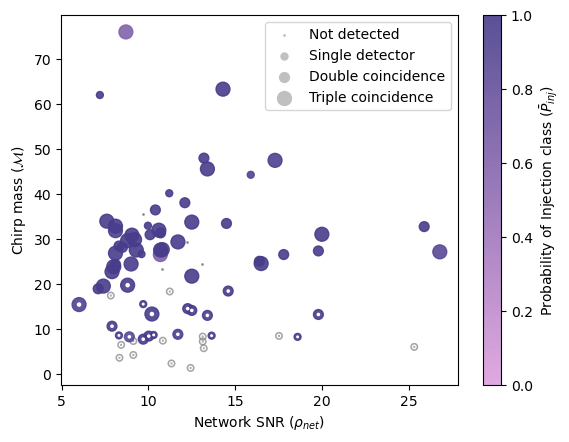

In [47]:
names, snrs, chirps, labels, probs, inhull = plotHarmonic(gwosc_table, gwosc_harmonic, getinHull(gwosc_table, mass_hull), 'GWOSCprobinj_new')

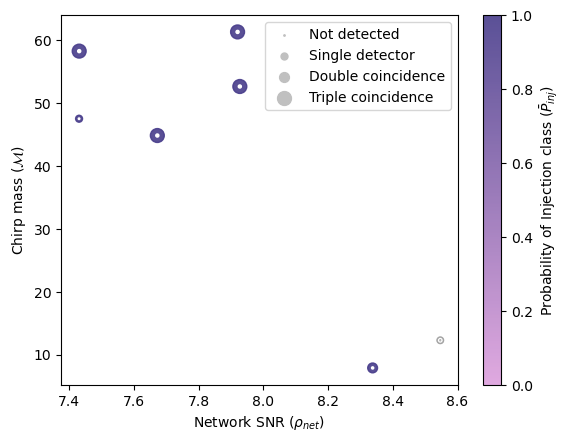

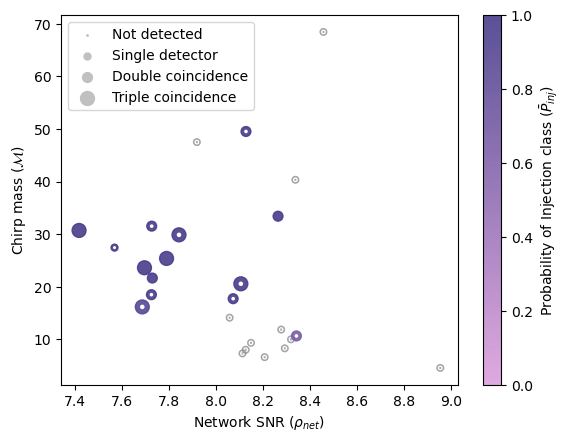

In [48]:
names_n1, snrs_n1, chirsp_n1, labels_n1, probs_n1, inhull_n1 = plotHarmonic(nitz_new,
                                                                            nitz_new_harm, getinHull(nitz_new, mass_hull), '4OGC_new')
names_n2, snrs_n2, chirsp_n2, labels_n2, probs_n2, inhull_n2 = plotHarmonic(nitz_sub,
                                                                            nitz_sub_harm, getinHull(nitz_sub, mass_hull), '4OGC_subthreshold')
#latexTable(names_n1, snrs_n1, chirsp_n1, labels_n1, probs_n1, inhull_n1)

In [49]:
princ_table = getEvents(catalog_princ)
princ_hull = getinHull(princ_table, mass_hull)
princ_harm = harmonicTable(princ_table)
princ_harm['inHUll'] = princ_hull
princ_table['inHUll'] = princ_hull

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourc

H1L1 0.9999557798504987


/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  max_per_row, _ = torch.max(torch.tensor(stat), dim=1)
/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/../FAR/utils/read.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourc

Name                                    GW190513_200230
Ifos                                               H1L1
SNR                                               12.49
Chirp mass                                        31.67
Probability                                        1.00
Cluster time    [1241816086.7506106, 1241816086.750368]
Num triggers                             [168.0, 241.0]
Name: 197, dtype: object

Index(['Name', 'GPS', 'SNR', 'Chirp mass', 'Mass1', 'Mass2', 'Ifos_H1',
       'SNR_H1', 'Chirp mass_H1', 'Probability_H1', 'Cluster time_H1',
       'Num triggers', 'Ifos_L1', 'SNR_L1', 'Chirp mass_L1', 'Probability_L1',
       'Cluster time_L1', 'Num triggers_L1', 'Ifos_V1', 'SNR_V1',
       'Chirp mass_V1', 'Probability_V1', 'Cluster time_V1', 'Num triggers_V1',
       'Ifos_H1L1', 'SNR_H1L1', 'Chirp mass_H1L1', 'Probability_H1L1',
       'Cluster time_H1L1', 'Num triggers_H1L1', 'Ifos_H1V1', 'SNR_H1V1',
       'Chirp mass_H1V1', 'Probability_H1V1', 'Cluster time_H1V1',
       'Num triggers_H1V1', 'Ifos_L1V1', 'SNR_L1V1', 'Chirp mass_L1V1',
       'Probability_L1V1', 'Cluster time_L1V1', 'Num triggers_L1V1'],
      dtype='object')


GW190503_180206
GW191215_220254
GW200225_070236
GW191122_210226


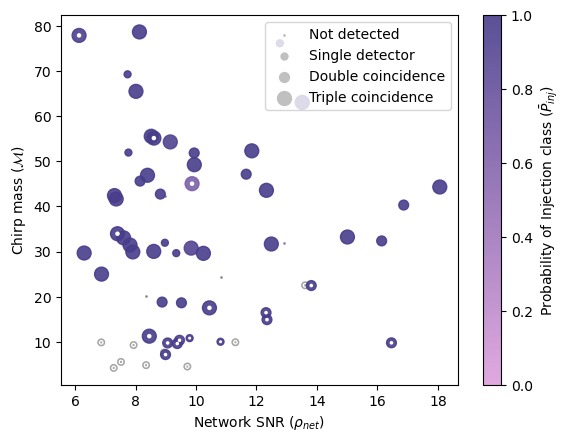

In [50]:
names_p, snrs_p, chirsp_p, labels_p, probs_p, inhull_p = plotHarmonic(princ_table, 
                                                                            princ_harm, getinHull(princ_table, mass_hull), 'Olsen')

In [51]:
# I want to add only the events above p-astri
princ_table['Catalog'] = 'Princeton'
nitz_new['Catalog'] = 'Nitz'
gwosc_table['Catalog'] = 'GWOSC'
allcatalogs = pd.concat([gwosc_table, nitz_new, princ_table])
allcatalogs = allcatalogs.reset_index(drop=True)
for ifo in ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']:
    if len(ifo) == 4:
        stat = 2/(1/allcatalogs['Probability_'+ifo[:2]].values + 1/allcatalogs['Probability_'+ifo[2:]].values)
    else:
        stat = 3/(1/allcatalogs['Probability_H1'].values + 1/allcatalogs['Probability_L1'].values+ 1/allcatalogs['Probability_V1'].values)
    allcatalogs['RS_'+ifo] = -np.log(1 - stat + 1e-20)
allcatalogs

/tmp/ipykernel_20234/1406220402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitz_new['Catalog'] = 'Nitz'


,Name,GPS,SNR,Chirp mass,Mass1,Mass2,Ifos_H1,SNR_H1,Chirp mass_H1,Probability_H1,...,Chirp mass_L1V1,Probability_L1V1,Cluster time_L1V1,Num triggers_L1V1,inHUll,Catalog,RS_H1L1,RS_H1V1,RS_L1V1,RS_H1L1V1
0,GW190403_051519,1238303737.20,7.60,34.00,85.00,20.00,H1,7.60,34.00,1.00,...,34.00,1.00,"[1238303737.236096, 1238303737.240158]","[18.0, 1.0]",o,GWOSC,12.20,12.20,25.50,12.60
1,GW190408_181802,1238782700.20,14.60,18.50,24.80,18.50,NaN,NaN,NaN,NaN,...,18.50,1.00,"[1238782700.2859044, 1238782700.2885582]","[82.0, 1.0]",p,GWOSC,NaN,NaN,46.05,NaN
2,GW190412,1239082262.10,19.80,13.30,27.70,9.00,NaN,NaN,NaN,NaN,...,13.30,1.00,"[1239082262.164922, 1239082262.1794188]","[71.0, 13.0]",p,GWOSC,NaN,NaN,7.99,NaN
3,GW190413_052954,1239168612.50,9.00,24.50,33.70,24.20,H1,9.00,24.50,0.96,...,NaN,NaN,NaN,NaN,o,GWOSC,3.82,NaN,NaN,NaN
4,GW190413_134308,1239198206.70,9.97,33.00,47.50,31.80,H1,9.97,33.00,1.00,...,NaN,NaN,NaN,NaN,o,GWOSC,NaN,13.40,NaN,NaN
5,GW190421_213856,1239917954.20,10.70,31.40,42.00,32.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,o,GWOSC,NaN,NaN,NaN,NaN
6,GW190424_180648,1240164426.10,10.09,31.00,40.50,31.80,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,o,GWOSC,NaN,NaN,NaN,NaN
7,GW190425,1240215503.00,12.40,1.44,2.10,1.30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,p,GWOSC,NaN,NaN,NaN,NaN
8,GW190426_190642,1240340820.60,8.70,76.00,105.50,76.00,H1,8.70,76.00,1.00,...,76.00,0.67,"[1240340820.6754687, 1240340820.6412294]","[90.0, 65.0]",o,GWOSC,1.12,21.41,1.12,1.41
9,GW190503_185404,1240944862.20,12.20,29.30,41.30,28.30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,o,GWOSC,NaN,NaN,NaN,NaN


In [56]:
allcatalogs.to_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

In [89]:
for cols in allcatalogs.columns:
    if 'Probability' in cols:
        label = cols[12:]
        stat = np.asarray(allcatalogs[cols].values, dtype=float)
        stat = -np.log(1 -stat + 1e-11)
        allcatalogs['Stat_rank_'+label] = stat

In [90]:
#allcatalogs.to_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

In [72]:
#latexTable(names_p, snrs_p, chirsp_p, labels_p, probs_p, inhull_p )

In [24]:
def results(names, snrs, chirps, labels, probs, inhull, file):
    gw_events_new = pd.DataFrame({'Name':names, 'rho':snrs,  'M':chirps, 'I':labels, 'P\_inj':probs, 'inHull':inhull})
    gw_events_new = gw_events_new.replace('_','\_', regex=True)
    path = '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/datasets/'
    gw_events_new.to_csv(path +file + '.csv')


In [30]:
results(names, snrs, chirps, labels, probs, inhull, 'reducedGWOSC')
results(names_n1, snrs_n1, chirsp_n1, labels_n1, probs_n1, inhull_n1, 'reducedNitz')
results(names_p, snrs_p, chirsp_p, labels_p, probs_p, inhull_p, 'reducedPrinceton')

In [20]:
probs_p

[0.9999562861785376, 1.0, 1.0, 0.9999866496435456, 1.0, 0.9999673645366587]

AresGW catalog (lacking SNR and Chirp mass)

In [26]:
#Event NameGPS Time Pastro FAR Time delay 
gws = ['GW190511_135545', 'GW190614_144749', 'GW190607_093827','GW200208_211609',
       'GW190705_174632', 'GW190424_170208', 'GW190629_085648',
       'GW190503_154609', 'GW190809_155440', 'GW190607_233923', 'GW190520_005107', 
       'GW190427_054847', 'GW190416_080520', 'GW200203_235815', 'GW190810_085214',
       'GW190405_062027']
times = [1241614563.77, 1244555287.93, 1243931925.99,  1265231787.68, 1246380410.88,  1240156946.51,
1245830226.79,  1240929987.65,  1249397698.41,  1243982381.42,  1242345085.55, 1240386545.71,
 1239433520.84,  1264809513.19,  1249458753.03,  1238476845.84]
pastro = [1.00, 1.00,0.99 ,0.99 , 0.96 , 0.91, 0.87, 0.84 , 0.82 , 0.80, 0.80 ,
0.76, 0.76 , 0.75 , 0.67 , 0.60]
print(len(gws), len(times), len(pastro))
aresgw = pd.DataFrame({'commonName': gws, 'GPS': times, 'pastro': pastro})
#aresgw.to_csv('./AresGW.csv')

16 16 16


In [27]:
aresgw_table = getEvents_(aresgw)

In [35]:
aresgw_table['Probability_H1L1']

0     nan
1    1.00
2    0.94
3    1.00
4    1.00
5    0.95
6    0.91
7    1.00
8     nan
9     nan
10   1.00
11   0.90
12   1.00
13   1.00
14    nan
15    nan
Name: Probability_H1L1, dtype: float64

In [33]:
timesgw = pd.concat([gwosc_table['GPS'], nitz_new['GPS'],
                     princ_table['GPS'], aresgw_table['GPS']])
namesgw = pd.concat([gwosc_table['Name'], nitz_new['Name'],
                     princ_table['Name'], aresgw_table['Name']])
allevents = pd.concat([namesgw, timesgw], axis=1)
allevents = allevents.reset_index(drop=True)
allevents.to_csv('little_dogs.csv')

In [37]:
ld = allevents.iloc[0]['GPS']
ld

1238303737.2

In [39]:
!pwd

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper


In [35]:
ifos = 'H1'
tmp = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_'+ifos+'.csv').columns

Index(['Unnamed: 0', 'SNR', 'Chisq', 'Mass_1', 'Mass_2', 'Spin1z', 'Spin2z',
       'Prob0', 'Prob1', 'Prob2', 'Prob3', 'Prob4', 'Prob5', 'Prob6',
       'Num triggers', 'Cluster ID', 'Cluster time'],
      dtype='object')

In [38]:
!ls ../output_new/tw0.05/predictions/

pred_known_H1_O3a.csv	      pred_nodogs_unknown_H1.csv
pred_known_H1_O3b.csv	      pred_nodogs_unknown_L1.csv
pred_known_L1_O3a.csv	      pred_nodogs_unknown_V1.csv
pred_known_L1_O3b.csv	      pred_unknown_H1.csv
pred_known_V1_O3a.csv	      pred_unknown_H1L1.csv
pred_known_V1_O3b.csv	      pred_unknown_H1L1V1.csv
pred_nodogs_known_H1_O3a.csv  pred_unknown_H1V1.csv
pred_nodogs_known_H1_O3b.csv  pred_unknown_L1.csv
pred_nodogs_known_L1_O3a.csv  pred_unknown_L1V1.csv
pred_nodogs_known_L1_O3b.csv  pred_unknown_V1.csv
pred_nodogs_known_V1_O3a.csv  TimeSlides.ipynb
pred_nodogs_known_V1_O3b.csv
